# Statistical Tests

## Imports

In [15]:
import warnings
warnings.filterwarnings("ignore") 
import logging
logging.disable(logging.CRITICAL)
import os
import time
import ast

%load_ext autoreload
%autoreload 2

import openpyxl
from openpyxl import load_workbook
from tqdm import tqdm_notebook as tqdm
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Statistical Tests

In [ ]:
# Loading
file_path = "result/dlr_result_Summary.xlsx"
df = pd.read_excel(file_path, sheet_name="dataset_summary")
output_dir = "output"

### Heatmap for each metric


Metric Testing: MAPE

Test:
Model       ARIMA  E. Smoot.  Linear R.       RNN  Transformer    N-HiTS  \
dataset                                                                    
chi      3.018026   8.411909   5.196672  1.710326     2.471353  2.542117   
ger      2.798199   8.210416   6.737874  2.256375     1.355427  1.803319   
tur      1.483768   9.150356   6.519082  1.294715     1.004332  1.030155   
usa      5.179081  19.135519   5.759568  3.681345     2.614335  2.344475   

Model         TCN   TSMixer   DLinear  
dataset                                
chi      1.295933  0.754236  1.564948  
ger      1.013714  2.599860  2.606060  
tur      0.623153  1.198254  0.683817  
usa      1.425865  2.550465  4.146107  

Friedman Test: Statistic=26.5333, p-value=0.0009

Significant difference, Nemenyi test executing...



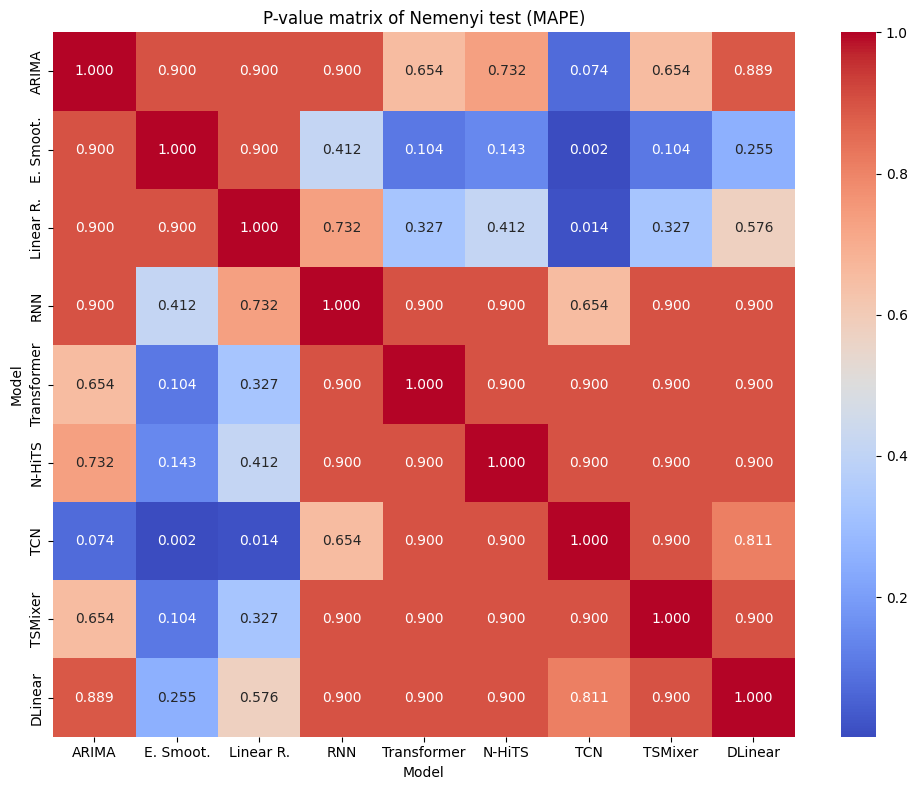

Heatmap saved: nemenyi_mape.png


Metric Testing: SMAPE

Test:
Model       ARIMA  E. Smoot.  Linear R.       RNN  Transformer    N-HiTS  \
dataset                                                                    
chi      2.958447   8.964129   5.044477  1.702492     2.438470  2.515717   
ger      2.755626   8.831137   6.418004  2.221126     1.357215  1.787143   
tur      1.468130   8.598336   6.272017  1.298216     0.998156  1.022830   
usa      5.438214  22.314538   5.602447  3.563748     2.621430  2.363107   

Model         TCN   TSMixer   DLinear  
dataset                                
chi      1.288105  0.752135  1.549462  
ger      1.004915  2.602884  2.590433  
tur      0.621207  1.190528  0.685582  
usa      1.433206  2.531156  4.086773  

Friedman Test: Statistic=26.4000, p-value=0.0009

Significant difference, Nemenyi test executing...



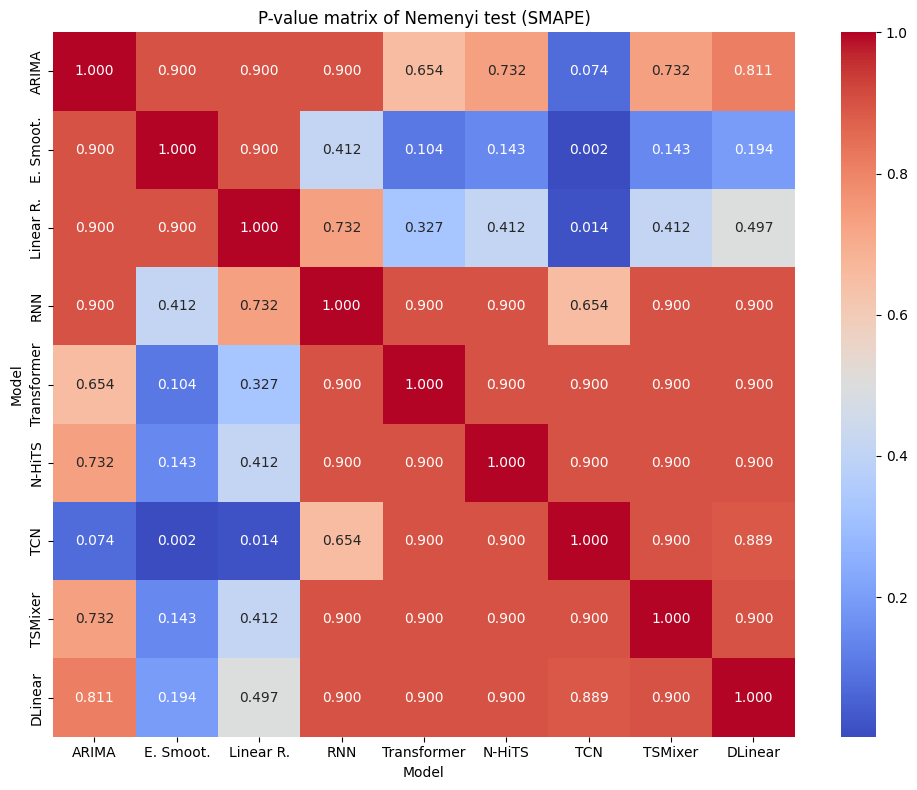

Heatmap saved: nemenyi_smape.png


Metric Testing: MASE

Test:
Model        ARIMA  E. Smoot.  Linear R.        RNN  Transformer     N-HiTS  \
dataset                                                                       
chi      14.508995  40.587939  25.094191   8.309131    12.048469  12.373175   
ger       8.806022  26.557475  21.105950   7.085537     4.317802   5.689001   
tur       7.006896  43.262205  31.096629   6.182505     4.749508   4.870694   
usa      15.553334  56.432246  16.001853  10.094497     7.502835   6.706844   

Model         TCN   TSMixer    DLinear  
dataset                                 
chi      6.303678  3.657556   7.534926  
ger      3.190149  8.312753   8.271717  
tur      2.959673  5.671328   3.272097  
usa      4.109170  7.551498  11.612169  

Friedman Test: Statistic=26.5333, p-value=0.0009

Significant difference, Nemenyi test executing...



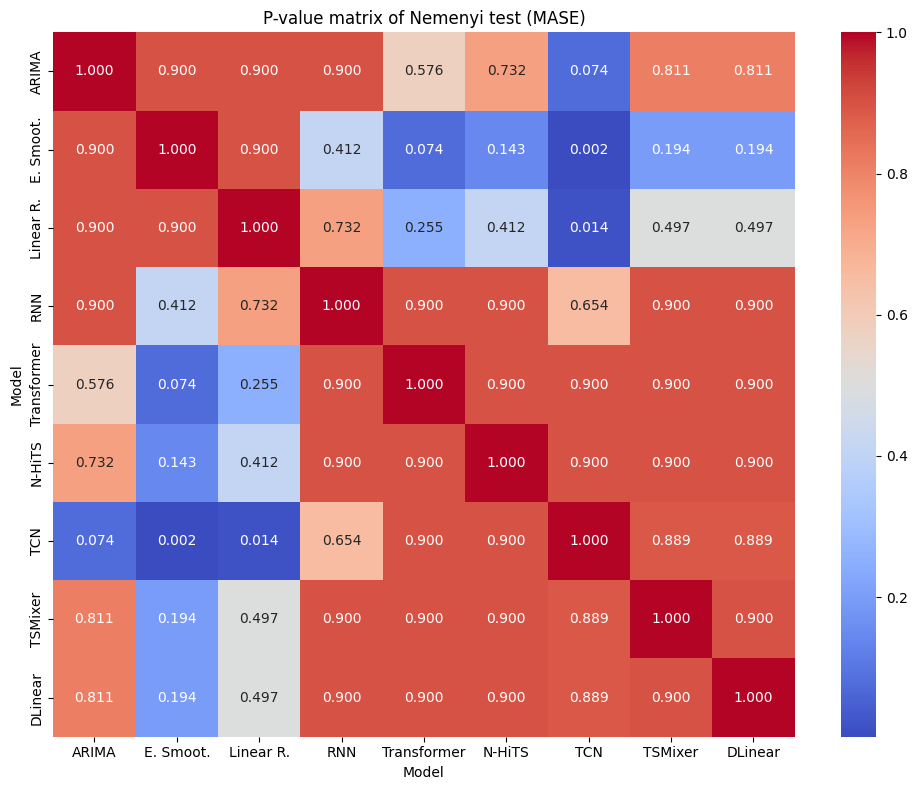

Heatmap saved: nemenyi_mase.png


Metric Testing: MARRE

Test:
Model        ARIMA   E. Smoot.   Linear R.        RNN  Transformer     N-HiTS  \
dataset                                                                         
chi      42.094071  117.755337   72.804263  24.106779    34.955495  35.897545   
ger      31.426684   94.777568   75.322319  25.286664    15.409251  20.302748   
tur      27.849376  171.948513  123.595619  24.572778    18.877237  19.358895   
usa      27.994769  101.573572   28.802067  18.169294    13.504508  12.071788   

Model          TCN    TSMixer    DLinear  
dataset                                   
chi      18.288480  10.611447  21.860627  
ger      11.384915  29.666319  29.519871  
tur      11.763418  22.541072  13.005166  
usa       7.396181  13.592098  20.900984  

Friedman Test: Statistic=26.5333, p-value=0.0009

Significant difference, Nemenyi test executing...



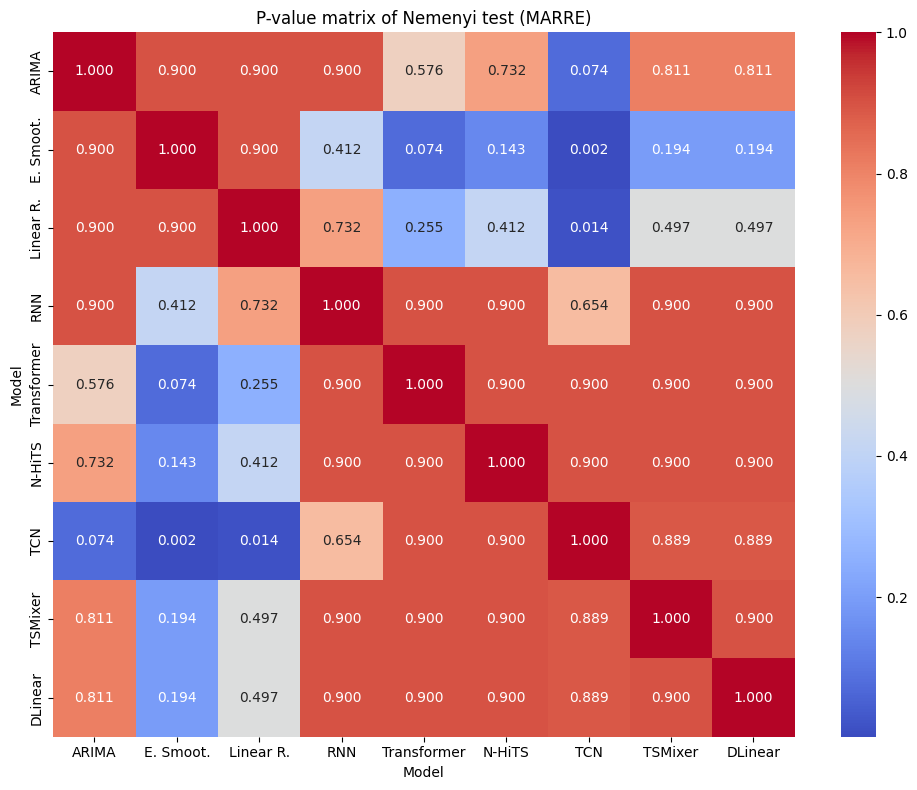

Heatmap saved: nemenyi_marre.png



In [49]:
metrics = ['MAPE', 'SMAPE', 'MASE', 'MARRE']

models = [
    'ARIMA',
    'E. Smoot.',
    'Linear R.',
    'RNN',
    'Transformer',
    'N-HiTS',
    'TCN',
    'TSMixer',
    'DLinear'
]

for metric in metrics:
    print(f"\n{'='*50}\nMetric Testing: {metric}\n{'='*50}")

    data = df.pivot(index='dataset', columns='Model', values=metric)

    actual_models = [m for m in models if m in data.columns]
    data = data[actual_models]

    print("\nTest:")
    print(data)
    
    # Friedman Test
    try:
        stat, p_value = stats.friedmanchisquare(*[data[model].dropna() for model in data.columns])
        print(f"\nFriedman Test: Statistic={stat:.4f}, p-value={p_value:.4f}")

        if p_value < 0.05:
            print("\nSignificant difference, Nemenyi test executing...\n")
            
            # Nemenyi Test
            nemenyi_results = sp.posthoc_nemenyi_friedman(data.values)
            nemenyi_results.columns = data.columns
            nemenyi_results.index = data.columns
            
            # Plot
            plt.figure(figsize=(10, 8))
            sns.heatmap(nemenyi_results, annot=True, cmap="coolwarm", fmt=".3f")
            plt.title(f"P-value matrix of Nemenyi test ({metric})")
            plt.tight_layout()
            file_path = os.path.join(output_dir, f"Final_Test_Nemenyi_{metric.lower()}.png")
            plt.savefig(file_path, dpi=300, bbox_inches='tight')
            plt.show()
            print(f"Heatmap saved: nemenyi_{metric.lower()}.png\n")
        else:
            print("\nAny difference between the models.")
    except ValueError as e:
        print(f"Error running the test {metric}: {e}")



### Clustermap - SMAPE


Metric Testing: SMAPE

Test Data:
Model       ARIMA  E. Smoot.  Linear R.       RNN  Transformer    N-HiTS  \
dataset                                                                    
chi      2.958447   8.964129   5.044477  1.702492     2.438470  2.515717   
ger      2.755626   8.831137   6.418004  2.221126     1.357215  1.787143   
tur      1.468130   8.598336   6.272017  1.298216     0.998156  1.022830   
usa      5.438214  22.314538   5.602447  3.563748     2.621430  2.363107   

Model         TCN   TSMixer   DLinear  
dataset                                
chi      1.288105  0.752135  1.549462  
ger      1.004915  2.602884  2.590433  
tur      0.621207  1.190528  0.685582  
usa      1.433206  2.531156  4.086773  

Friedman Test: Statistic=26.4000, p-value=0.0009

Significant difference, Nemenyi test executing...

  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the

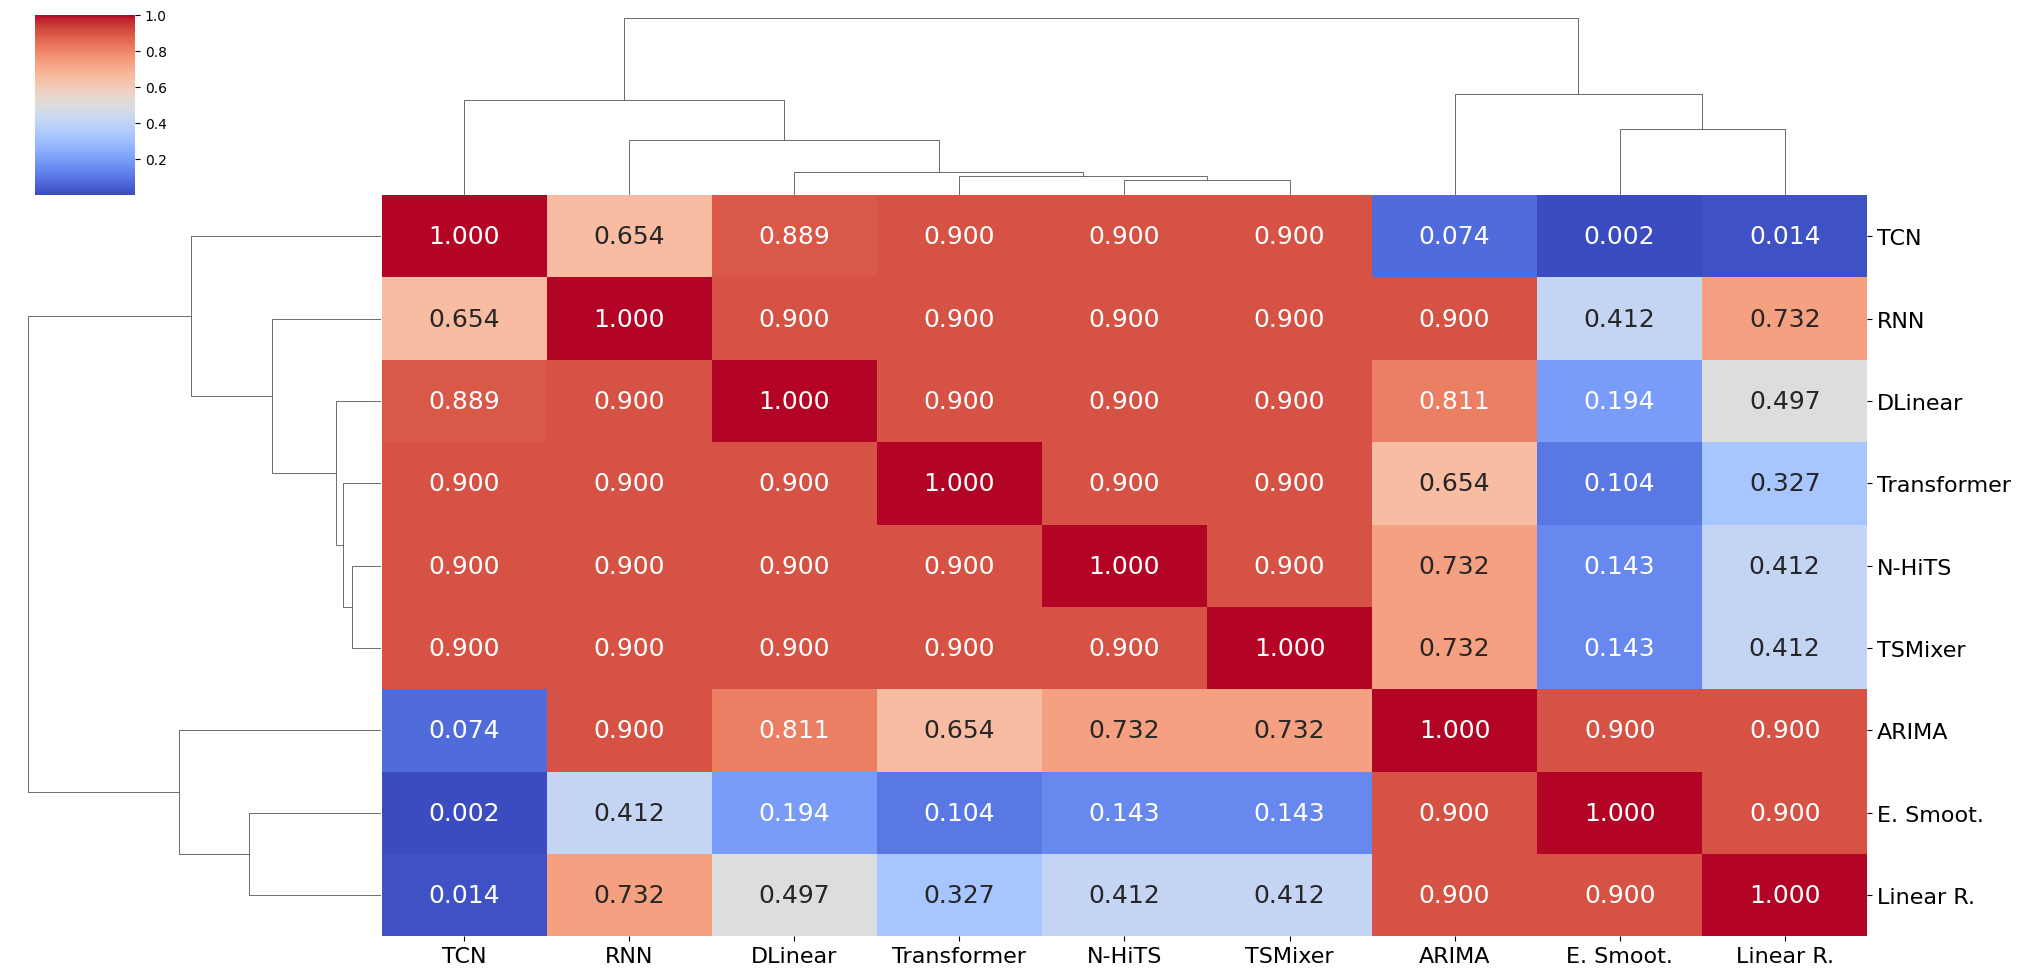

Clustermap saved: nemenyi_clustermap_smape.png



In [48]:
metric = 'SMAPE'

models = [
    'ARIMA',
    'E. Smoot.',
    'Linear R.',
    'RNN',
    'Transformer',
    'N-HiTS',
    'TCN',
    'TSMixer',
    'DLinear'
]

print(f"\n{'='*50}\nMetric Testing: {metric}\n{'='*50}")

data = df.pivot(index='dataset', columns='Model', values=metric)

actual_models = [m for m in models if m in data.columns]
data = data[actual_models]

print("\nTest Data:")
print(data)

# Friedman Test
try:
    stat, p_value = stats.friedmanchisquare(*[data[model].dropna() for model in data.columns])
    print(f"\nFriedman Test: Statistic={stat:.4f}, p-value={p_value:.4f}")

    if p_value < 0.05:
        print("\nSignificant difference, Nemenyi test executing...\n")
        
        nemenyi_results = sp.posthoc_nemenyi_friedman(data.values)
        nemenyi_results.columns = data.columns
        nemenyi_results.index = data.columns
        g = sns.clustermap(
            nemenyi_results, 
            annot=True,
            cmap="coolwarm",
            figsize=(20, 10),
            fmt=".3f"
        )
        g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=16)
        g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=16)
        plt.setp(g.ax_heatmap.get_xticklabels())
        g.ax_heatmap.set_xlabel('')
        g.ax_heatmap.set_ylabel('')
        for text in g.ax_heatmap.texts:
            text.set_fontsize(18)
        file_path = os.path.join(output_dir, f"Final_Test_Clustermap_{metric.lower()}.png")
        plt.savefig(file_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Clustermap saved: nemenyi_clustermap_{metric.lower()}.png\n")
    else:
        print("\nAny significant difference between the models.")
except ValueError as e:
    print(f"Error running the test {metric}: {e}")

### Violin - MASE

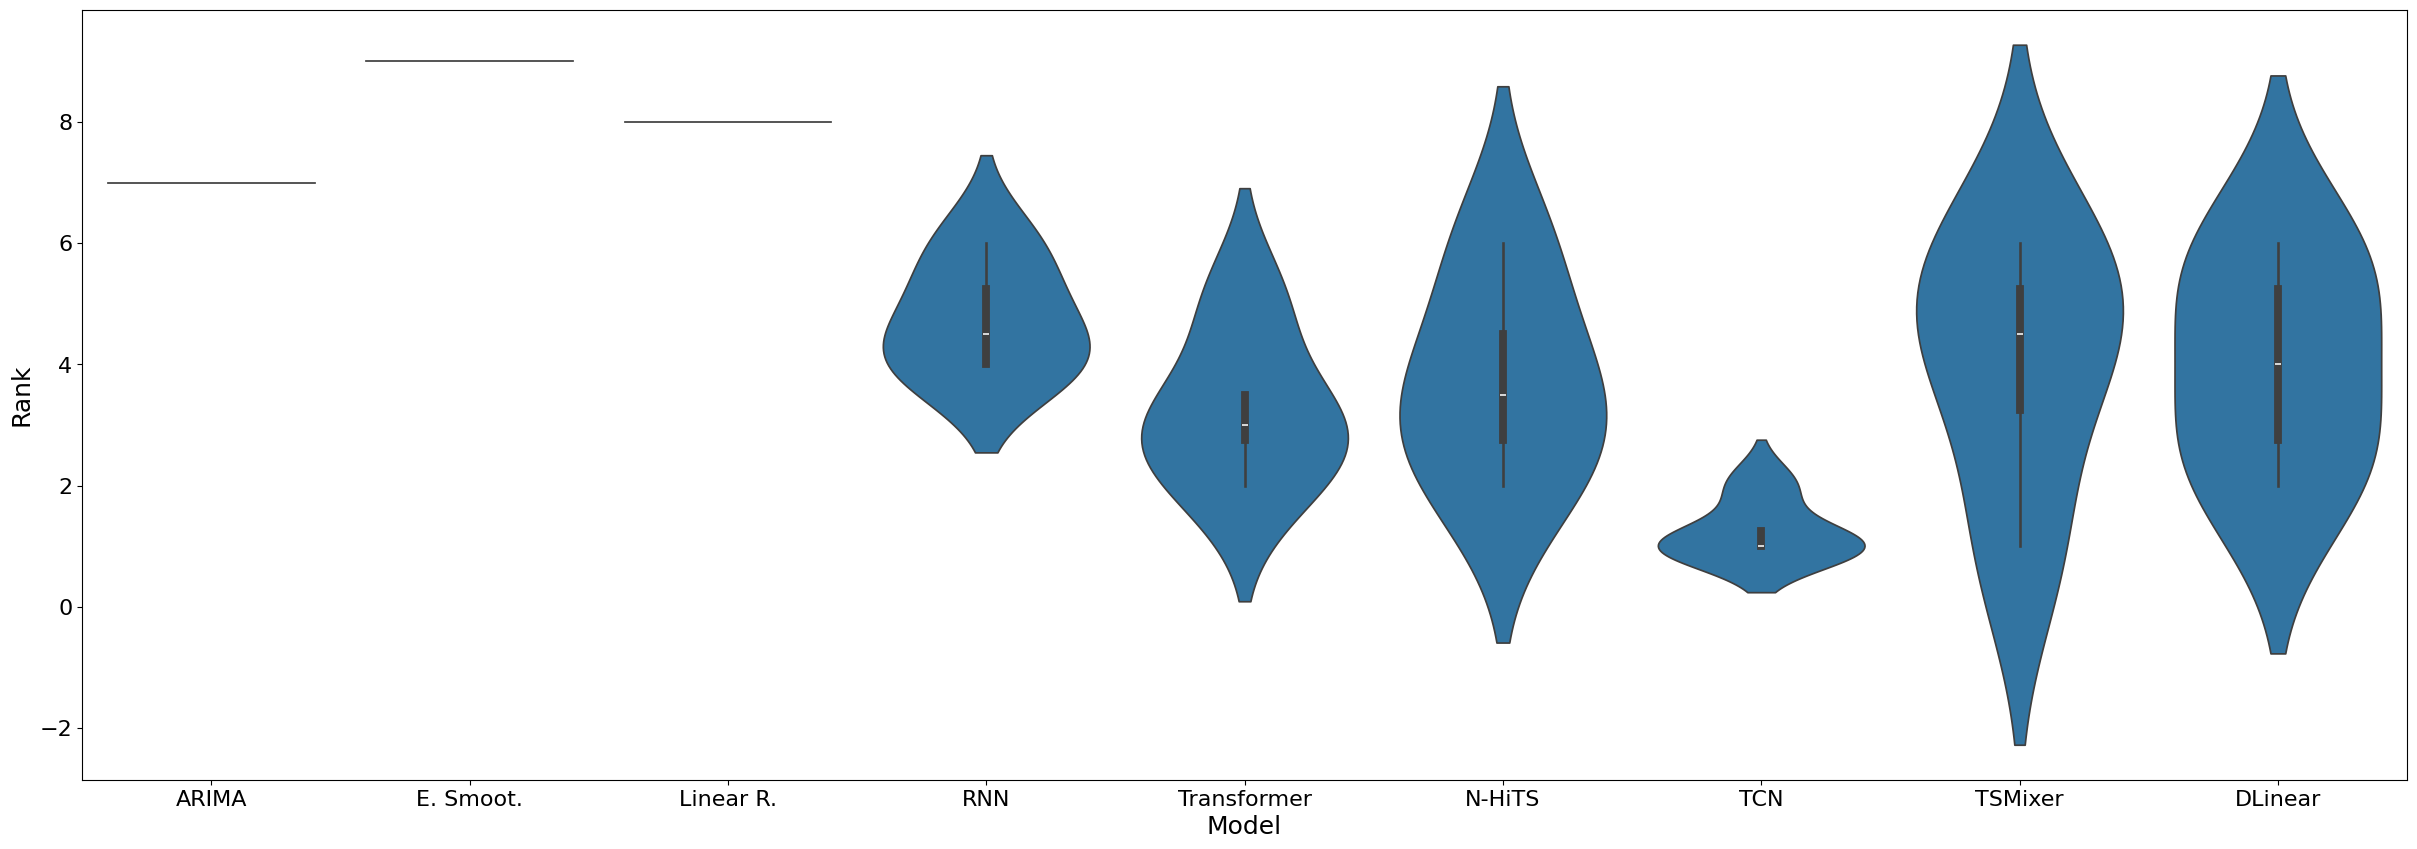

In [47]:
df['Rank'] = df.groupby('dataset')['MASE'].rank(method='min')
df_rank = df[['dataset', 'Model', 'Rank']]

model_order = [
    'ARIMA',
    'E. Smoot.',
    'Linear R.',
    'RNN',
    'Transformer',
    'N-HiTS',
    'TCN',
    'TSMixer',
    'DLinear'
]

default_color = sns.color_palette()[0] 
custom_palette = [
    'gray' if model in ['ARIMA', 'E. Smoot.', 'Linear R.'] else default_color 
    for model in model_order
]

plt.figure(figsize=(30, 10))
sns.violinplot(
    data=df_rank, 
    x='Model', 
    y='Rank', 
    order=model_order,
    palette=custom_palette
)

plt.xlabel('Model', fontsize=18)
plt.ylabel('Rank', fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
file_path = os.path.join(output_dir, f"Final_Test_Violin.png")
plt.savefig(file_path, dpi=300, bbox_inches='tight')
plt.show()

### KDE

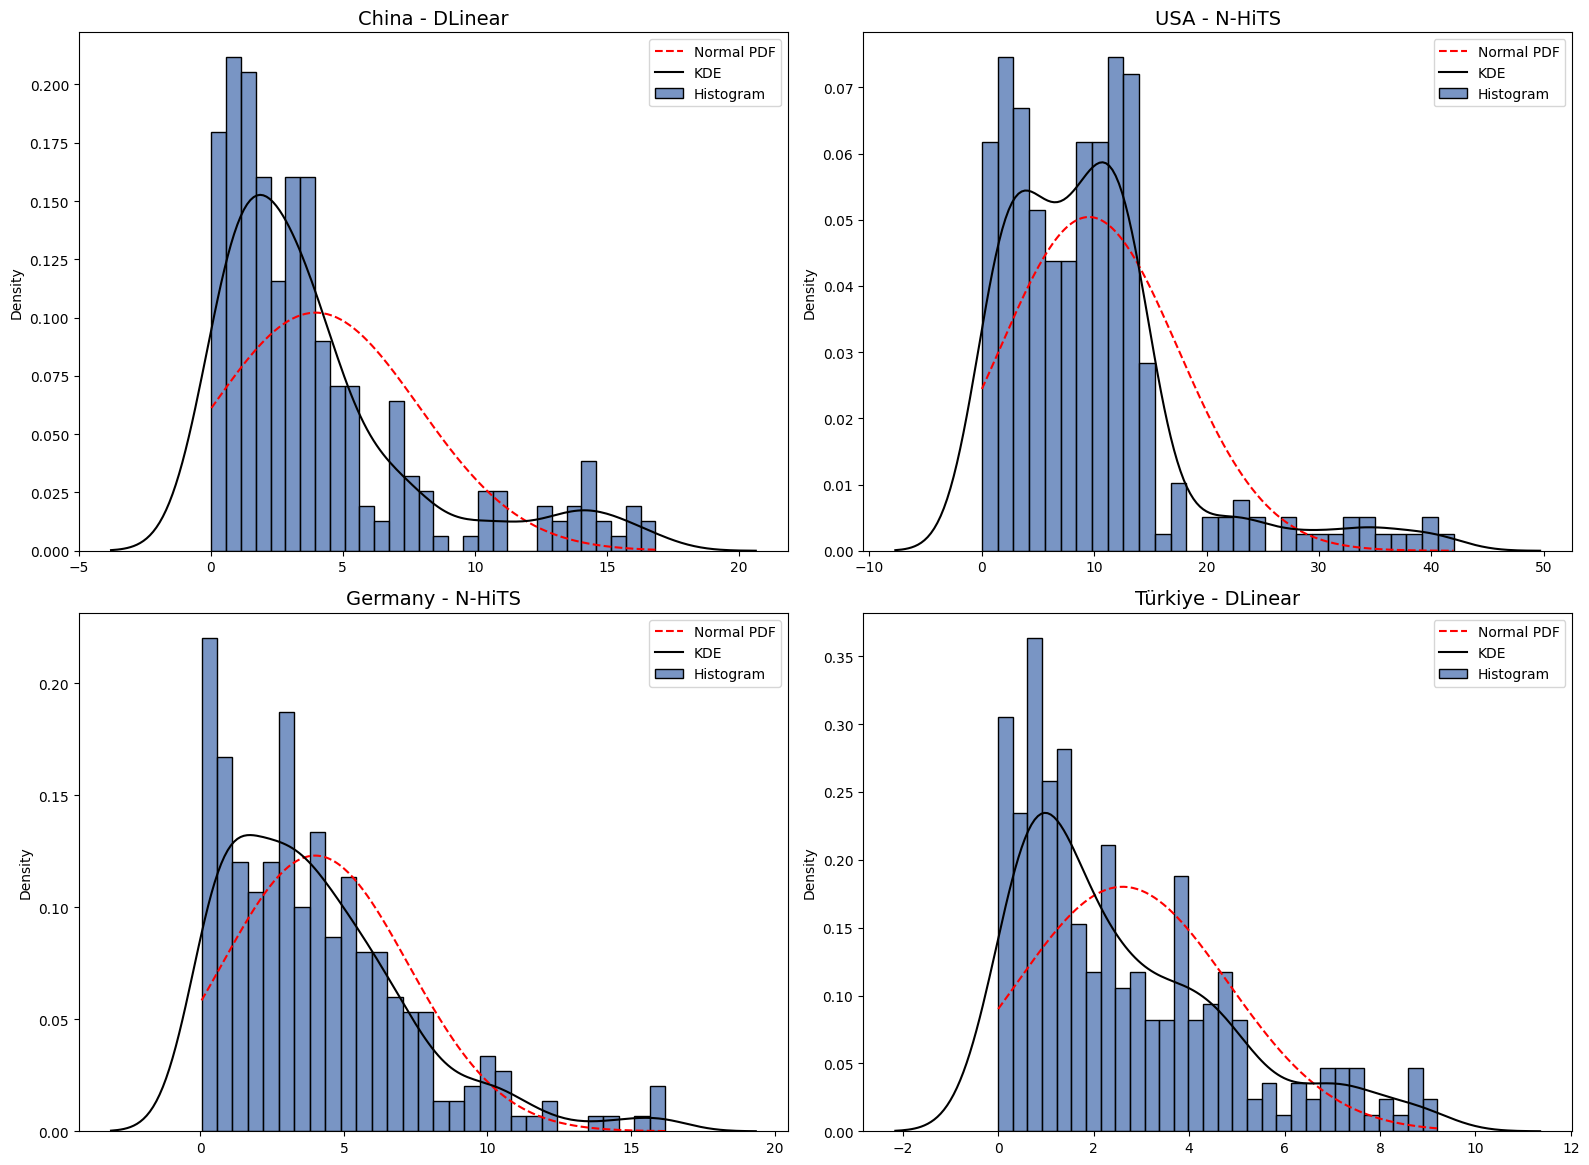

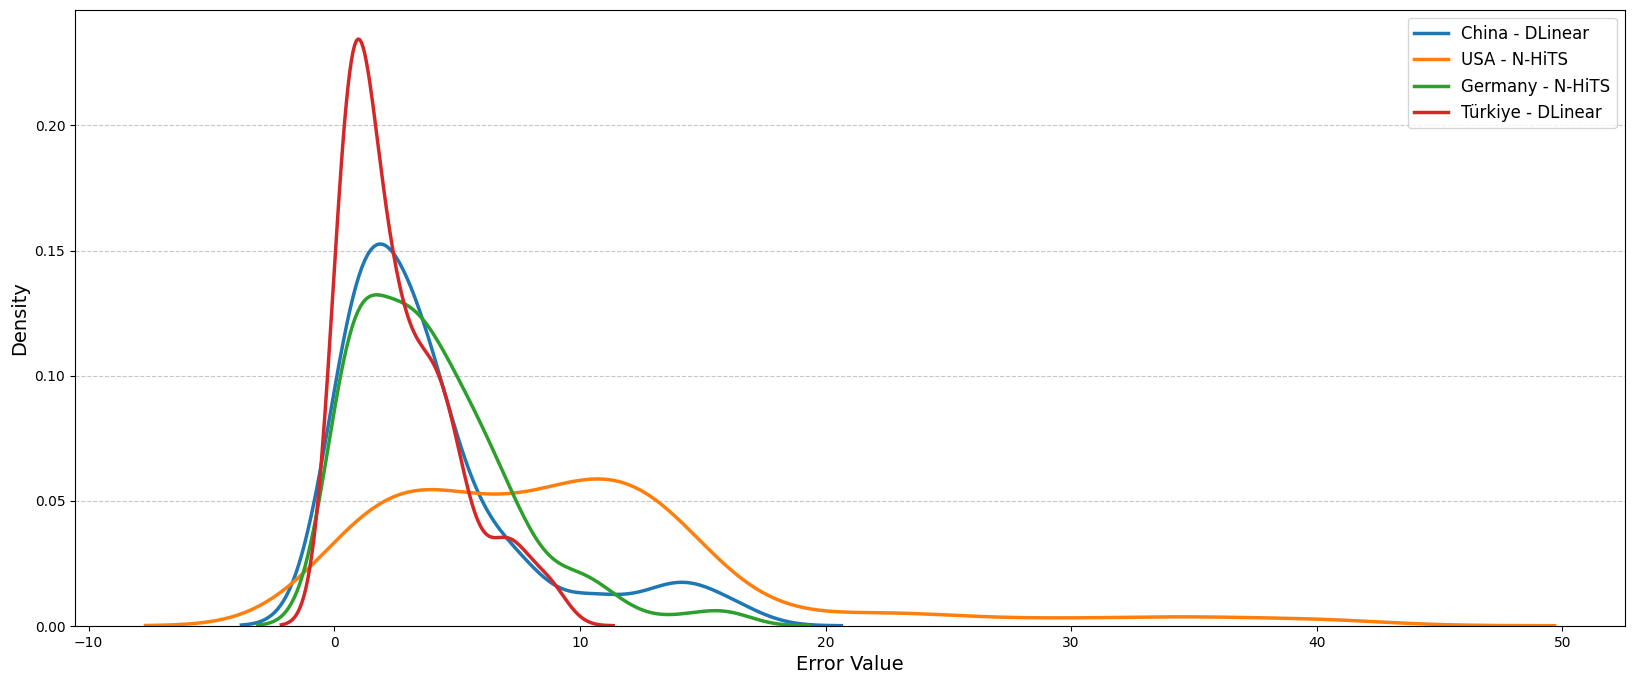

In [51]:
file_path = "result/dlr_result_Summary.xlsx"
df_errors = pd.read_excel(file_path, sheet_name="best_curves")
column_map = {
    'chi_dlinear_error': 'China - DLinear',
    'usa_nhits_error': 'USA - N-HiTS',
    'ger_nhits_error': 'Germany - N-HiTS',
    'tur_dlinear_error': 'Türkiye - DLinear'
}
error_columns = list(column_map.keys())

# Histogram + PDF Normal + KDE
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(error_columns):
    data = df_errors[col].dropna()
    mean, std = data.mean(), data.std()
    # Density histogram
    sns.histplot(data, bins=30, kde=False, stat='density', ax=axes[i], color="#4C72B0", label='Histogram')
    # Normal Distribution Curve (PDF)
    x_vals = np.linspace(data.min(), data.max(), 200)
    y_vals = norm.pdf(x_vals, mean, std)
    axes[i].plot(x_vals, y_vals, color='red', linestyle='--', label='Normal PDF')
    # Kernel density curve (KDE)
    sns.kdeplot(data, ax=axes[i], color='black', linestyle='-', label='KDE')
    axes[i].set_title(column_map[col], fontsize=14)
    axes[i].set_ylabel("Density")
    axes[i].set_xlabel("")
    axes[i].legend()
plt.tight_layout(rect=[0, 0, 1, 0.98])
file_path = os.path.join(output_dir, f"Final_Test_KDE.png")
plt.savefig(file_path, dpi=300, bbox_inches='tight')
plt.show()


# KDE Comparison
plt.figure(figsize=(20, 8))

for col in error_columns:
    data = df_errors[col].dropna()
    sns.kdeplot(data, label=column_map[col], lw=2.5)
#plt.title("KDE Comparison of Error Distributions", fontsize=18)
plt.xlabel("Error Value", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
file_path = os.path.join(output_dir, f"Final_Test_KDE_Comparison.png")
plt.savefig(file_path, dpi=300, bbox_inches='tight')
plt.show()

### Error Boxplot

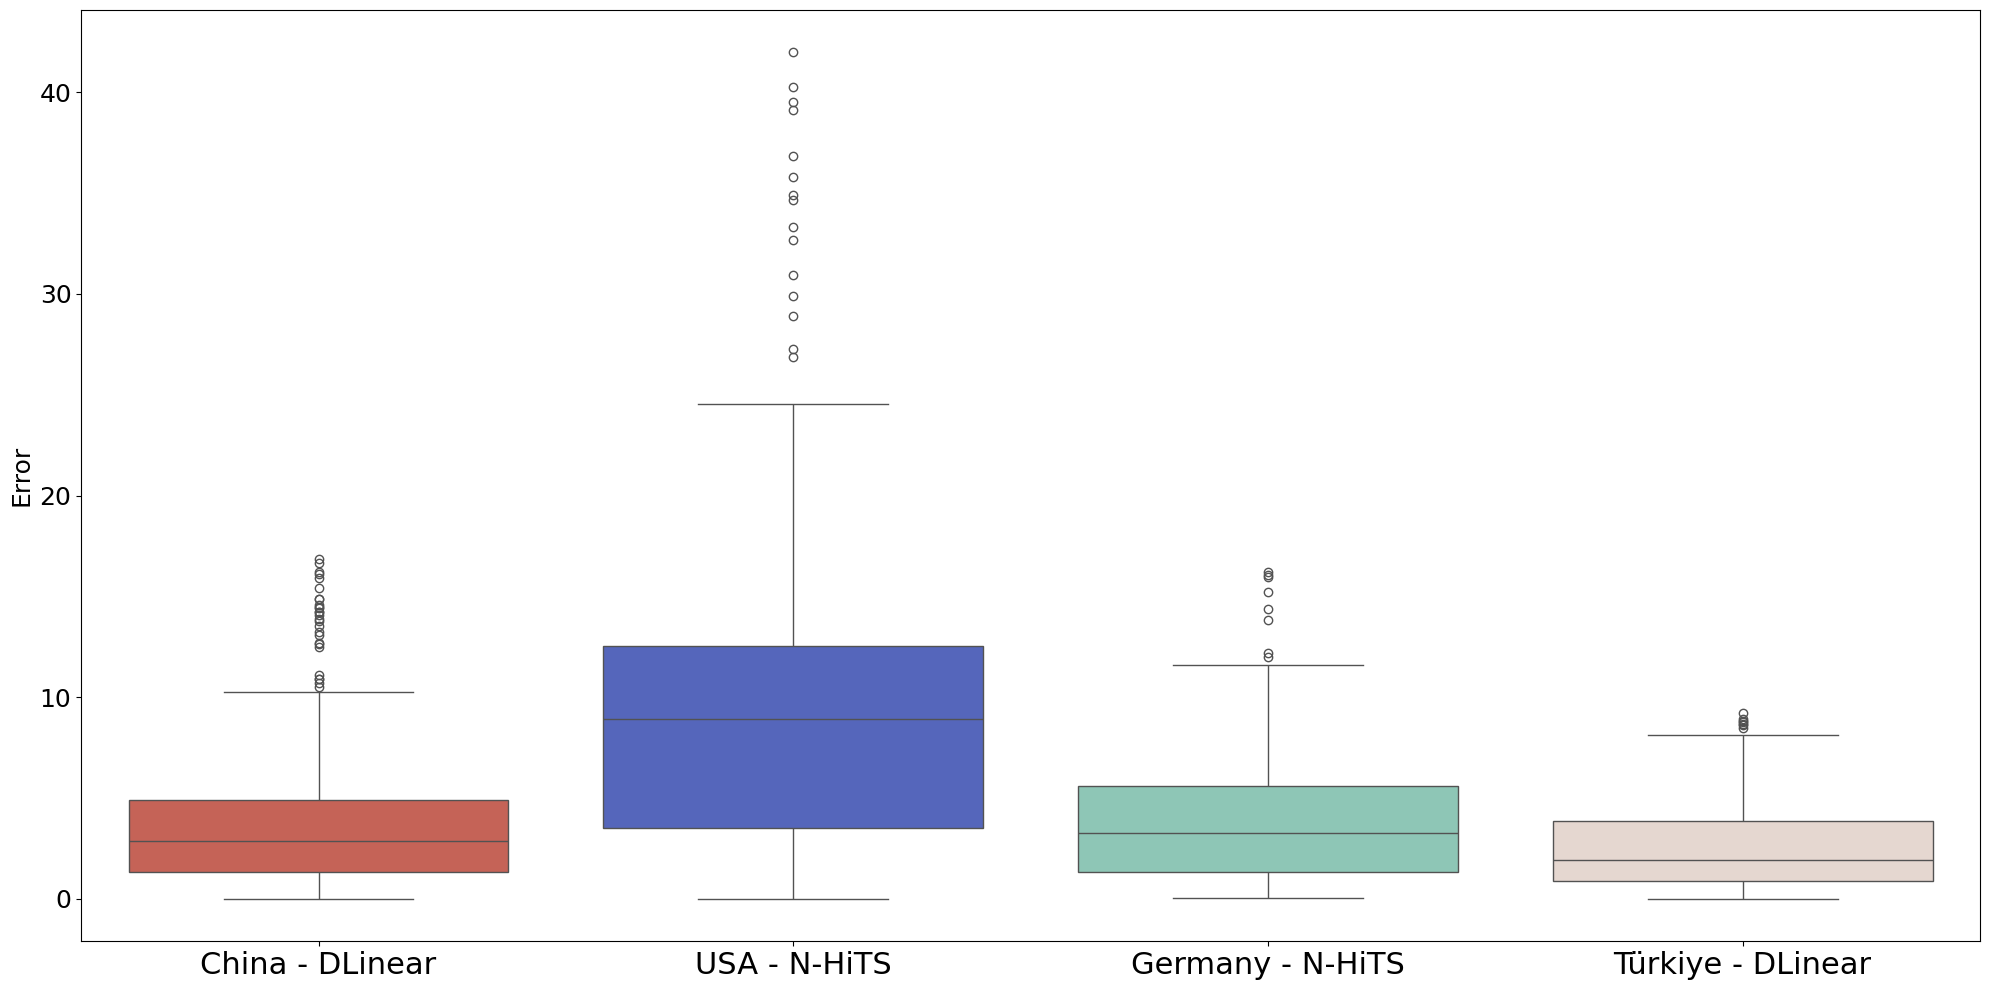

In [52]:
file_path = "result/dlr_result_Summary.xlsx"
df_errors = pd.read_excel(file_path, sheet_name="best_curves")
column_map = {
    'chi_dlinear_error': 'China - DLinear',
    'usa_nhits_error': 'USA - N-HiTS',
    'ger_nhits_error': 'Germany - N-HiTS',
    'tur_dlinear_error': 'Türkiye - DLinear'
}

df_plot = df_errors[list(column_map.keys())].rename(columns=column_map)
df_long = df_plot.melt(var_name="Dataset", value_name="Error")

custom_palette = [
    '#D75445',
    '#445ACC',
    '#85CFBA',
    '#E8D6CC',
]

plt.figure(figsize=(20, 10))
sns.boxplot(data=df_long, x="Dataset", y="Error", palette=custom_palette, showfliers=True)

#plt.title("Boxplot of Forecast Errors (Outliers Highlighted)", fontsize=14)
plt.xticks(rotation=0, fontsize=22)
plt.yticks(fontsize=18)
plt.xlabel("")
plt.ylabel("Error", fontsize=18)
plt.tight_layout()
file_path = os.path.join(output_dir, f"Final_Test_Boxplot.png")
plt.savefig(file_path, dpi=300, bbox_inches='tight')
plt.show()